<a href="https://colab.research.google.com/github/hercreater75-sketch/HR-Employee-Attrition-Analys/blob/main/Amrin_N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== HR ATTRITION ANALYSIS RESULTS ===

--- Attrition Rate by Department ---
 Department  Attrition_Rate_Pct
Engineering           22.395833
         HR           14.583333
  Marketing           13.207547
      Sales           19.480519

--- Attrition Rate by Salary Tier ---
Salary  Attrition_Rate_Pct
  High           23.076923
   Low           14.220183
Medium           21.989529

--- Attrition Rate by Experience Range ---
Experience_Group  Attrition_Rate_Pct
       0-3 Years           15.740741
       4-7 Years           22.500000
      8-11 Years           16.891892
       12+ Years           20.161290

--- Key Factors (Correlation with Attrition) ---
Employee_ID           0.040678
Satisfaction_Score    0.016188
Experience_Years      0.009648


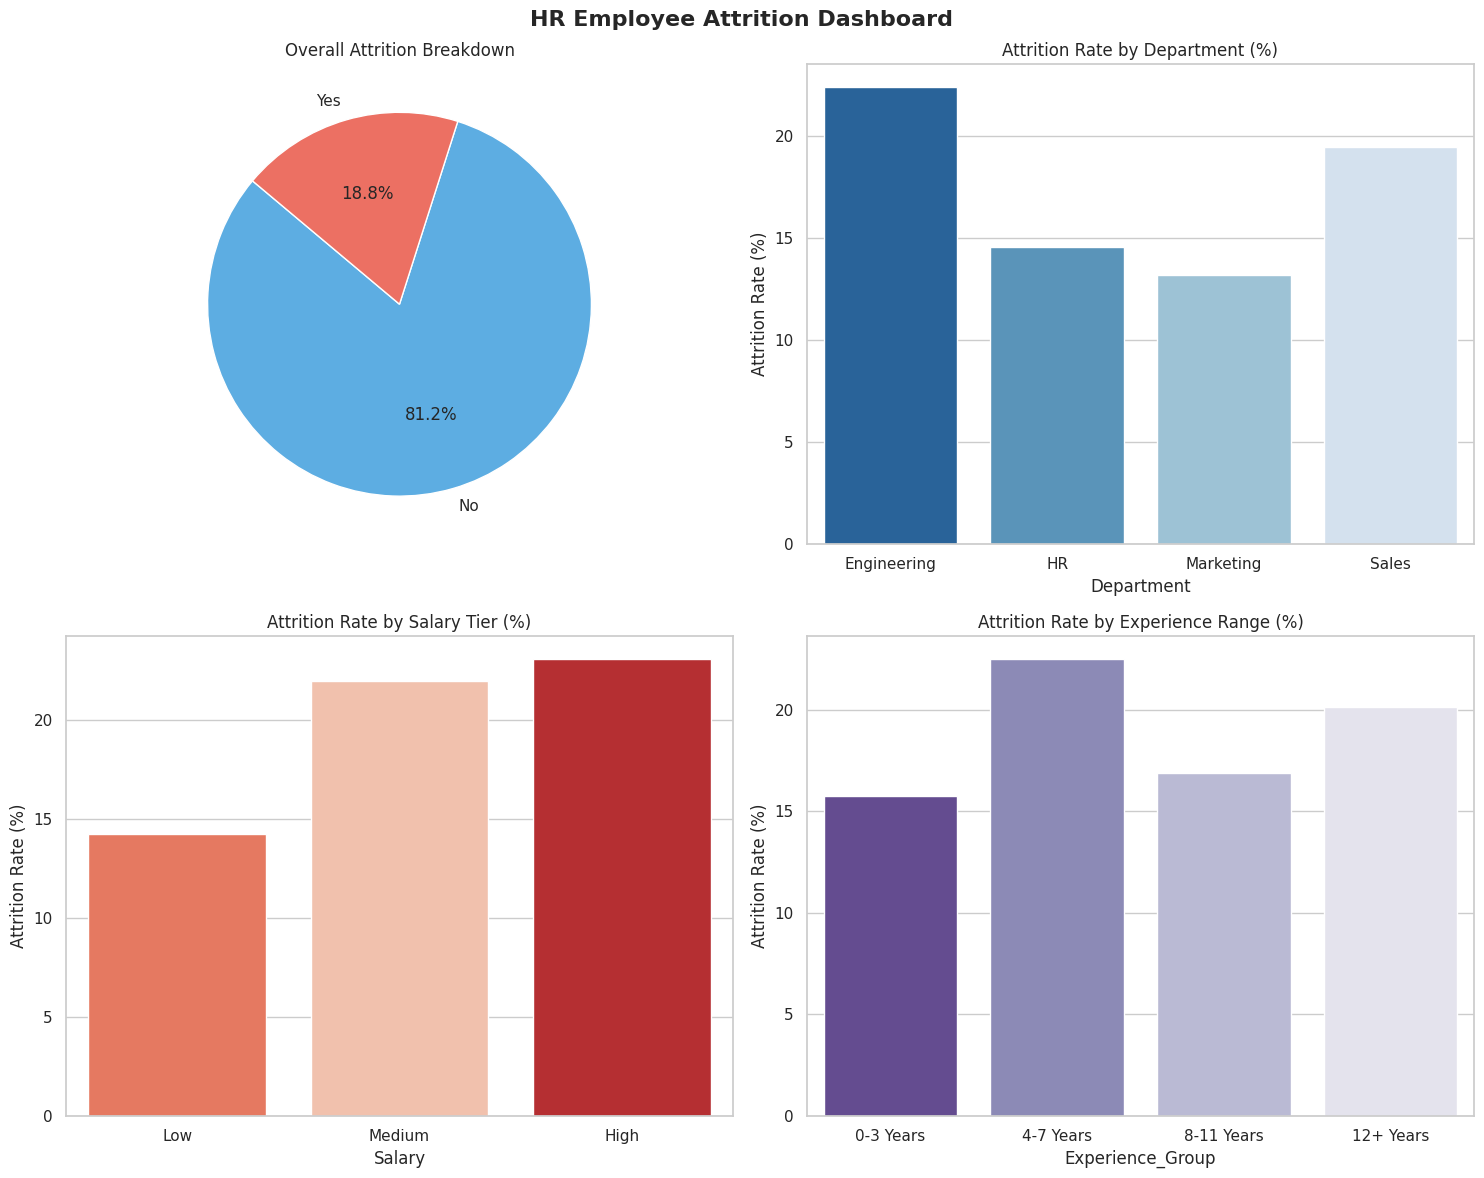

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. GENERATE DUMMY DATA FOR THE PROJECT
np.random.seed(42)
n_samples = 500

data = {
    "Employee_ID": range(1001, 1001 + n_samples),
    "Department": np.random.choice(
        ["Sales", "Engineering", "HR", "Marketing"], n_samples, p=[0.3, 0.4, 0.1, 0.2]
    ),
    "Salary": np.random.choice(
        ["Low", "Medium", "High"], n_samples, p=[0.4, 0.4, 0.2]
    ),
    "Experience_Years": np.random.randint(1, 15, size=n_samples),
    "Attrition": np.random.choice(["Yes", "No"], n_samples, p=[0.20, 0.80]),
    "Satisfaction_Score": np.random.randint(1, 6, size=n_samples),
}

df = pd.DataFrame(data)
df.loc[10:15, "Salary"] = np.nan
df.loc[20:22, "Experience_Years"] = -5

# 2. CLEAN EMPLOYEE DATASET
df["Salary"] = df["Salary"].fillna(df["Salary"].mode()[0])
df["Experience_Years"] = df["Experience_Years"].abs()
df["Attrition_Numeric"] = df["Attrition"].map({"Yes": 1, "No": 0})

# 3. ANALYZE ATTRITION RATE BY DEPARTMENT, SALARY, EXPERIENCE
dept_attrition = (
    df.groupby("Department")["Attrition_Numeric"].mean() * 100
).reset_index()
dept_attrition.columns = ["Department", "Attrition_Rate_Pct"]

salary_attrition = (
    df.groupby("Salary")["Attrition_Numeric"].mean() * 100
).reset_index()
salary_attrition.columns = ["Salary", "Attrition_Rate_Pct"]

df["Experience_Group"] = pd.cut(
    df["Experience_Years"],
    bins=[0, 3, 7, 11, 15],
    labels=["0-3 Years", "4-7 Years", "8-11 Years", "12+ Years"],
)
exp_attrition = (
    df.groupby("Experience_Group", observed=False)["Attrition_Numeric"].mean()
    * 100
).reset_index()
exp_attrition.columns = ["Experience_Group", "Attrition_Rate_Pct"]

# 4. IDENTIFY KEY FACTORS AFFECTING ATTRITION
numeric_cols = df.select_dtypes(include=[np.number])
correlation = (
    numeric_cols.corr()["Attrition_Numeric"]
    .sort_values(ascending=False)
    .drop("Attrition_Numeric")
)

print("=== HR ATTRITION ANALYSIS RESULTS ===")
print("\n--- Attrition Rate by Department ---")
print(dept_attrition.to_string(index=False))
print("\n--- Attrition Rate by Salary Tier ---")
print(salary_attrition.to_string(index=False))
print("\n--- Attrition Rate by Experience Range ---")
print(exp_attrition.to_string(index=False))
print("\n--- Key Factors (Correlation with Attrition) ---")
print(correlation.to_string())

# 5. VISUALIZE TRENDS (PIE CHARTS, BAR GRAPHS)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("HR Employee Attrition Dashboard", fontsize=16, fontweight="bold")

attrition_counts = df["Attrition"].value_counts()
axes[0, 0].pie(
    attrition_counts,
    labels=attrition_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#5dade2", "#ec7063"],
)
axes[0, 0].set_title("Overall Attrition Breakdown")

sns.barplot(
    x="Department",
    y="Attrition_Rate_Pct",
    data=dept_attrition,
    ax=axes[0, 1],
    hue="Department",
    palette="Blues_r",
    legend=False,
)
axes[0, 1].set_title("Attrition Rate by Department (%)")
axes[0, 1].set_ylabel("Attrition Rate (%)")

sns.barplot(
    x="Salary",
    y="Attrition_Rate_Pct",
    data=salary_attrition,
    ax=axes[1, 0],
    order=["Low", "Medium", "High"],
    hue="Salary",
    palette="Reds_r",
    legend=False,
)
axes[1, 0].set_title("Attrition Rate by Salary Tier (%)")
axes[1, 0].set_ylabel("Attrition Rate (%)")

sns.barplot(
    x="Experience_Group",
    y="Attrition_Rate_Pct",
    data=exp_attrition,
    ax=axes[1, 1],
    hue="Experience_Group",
    palette="Purples_r",
    legend=False,
)
axes[1, 1].set_title("Attrition Rate by Experience Range (%)")
axes[1, 1].set_ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()